<a href="https://colab.research.google.com/github/Manojmp7676/NATURAL-LANGUAGE-PROCESSING-NLP-/blob/main/Project_10_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install nltk wordcloud -q

# Import Libraries
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# Download NLTK Resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
data = {
    "Complaint":[

"My ATM deducted money but no cash was dispensed.",
"Unable to login to online banking.",
"My credit card payment is not updated.",
"Loan approval is taking too long.",
"Account was closed without notice.",
"Money transferred but receiver didn't get it.",
"Internet banking server is always down.",
"Debit card is blocked automatically.",
"Unauthorized transaction detected.",
"Balance is incorrect after withdrawal.",
"ATM cash not received.",
"Credit card charged twice.",
"Personal loan rejected without reason.",
"Net banking OTP not received.",
"Unable to reset password.",
"Savings account blocked.",
"Cheque not cleared.",
"UPI payment failed.",
"Mobile banking app crashes.",
"Refund not received."

]*20,

"Category":[

"ATM",
"Online Banking",
"Credit Card",
"Loan",
"Account",
"Transaction",
"Online Banking",
"Card",
"Fraud",
"Account",
"ATM",
"Credit Card",
"Loan",
"Online Banking",
"Online Banking",
"Account",
"Transaction",
"Transaction",
"Online Banking",
"Transaction"

]*20
}

df = pd.DataFrame(data)

print("Total Complaints:",len(df))
print(df.head())

Total Complaints: 400
                                          Complaint        Category
0  My ATM deducted money but no cash was dispensed.             ATM
1                Unable to login to online banking.  Online Banking
2            My credit card payment is not updated.     Credit Card
3                 Loan approval is taking too long.            Loan
4                Account was closed without notice.         Account


In [13]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()   # <-- use split(), NOT word_tokenize()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df["Processed"] = df["Complaint"].apply(preprocess)

print(df.head())

                                          Complaint        Category  \
0  My ATM deducted money but no cash was dispensed.             ATM   
1                Unable to login to online banking.  Online Banking   
2            My credit card payment is not updated.     Credit Card   
3                 Loan approval is taking too long.            Loan   
4                Account was closed without notice.         Account   

                           Processed  
0  atm deducted money cash dispensed  
1        unable login online banking  
2        credit card payment updated  
3          loan approval taking long  
4      account closed without notice  


In [14]:
vectorizer=TfidfVectorizer()

X=vectorizer.fit_transform(df["Processed"])

y=df["Category"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=LogisticRegression(max_iter=500)

model.fit(X_train,y_train)

prediction=model.predict(X_test)

accuracy=accuracy_score(y_test,prediction)

print("\nAccuracy:",accuracy)

print("\nClassification Report\n")

print(classification_report(y_test,prediction))


Accuracy: 1.0

Classification Report

                precision    recall  f1-score   support

           ATM       1.00      1.00      1.00         7
       Account       1.00      1.00      1.00        12
          Card       1.00      1.00      1.00         1
   Credit Card       1.00      1.00      1.00        10
         Fraud       1.00      1.00      1.00         3
          Loan       1.00      1.00      1.00         7
Online Banking       1.00      1.00      1.00        26
   Transaction       1.00      1.00      1.00        14

      accuracy                           1.00        80
     macro avg       1.00      1.00      1.00        80
  weighted avg       1.00      1.00      1.00        80



In [16]:
new_complaint="ATM deducted 5000 rupees but cash not received"

processed=preprocess(new_complaint)

vector=vectorizer.transform([processed])

result=model.predict(vector)

print("\nNew Complaint")

print(new_complaint)

print("Predicted Category:",result[0])


New Complaint
ATM deducted 5000 rupees but cash not received
Predicted Category: ATM


In [17]:
all_words=" ".join(df["Processed"])

word_list=all_words.split()

frequency=Counter(word_list)

print("\nTop 20 Frequent Words\n")

for word,count in frequency.most_common(20):
    print(word,"-",count)



Top 20 Frequent Words

banking - 80
card - 60
received - 60
atm - 40
money - 40
cash - 40
unable - 40
credit - 40
payment - 40
loan - 40
account - 40
without - 40
blocked - 40
deducted - 20
dispensed - 20
login - 20
online - 20
updated - 20
approval - 20
taking - 20


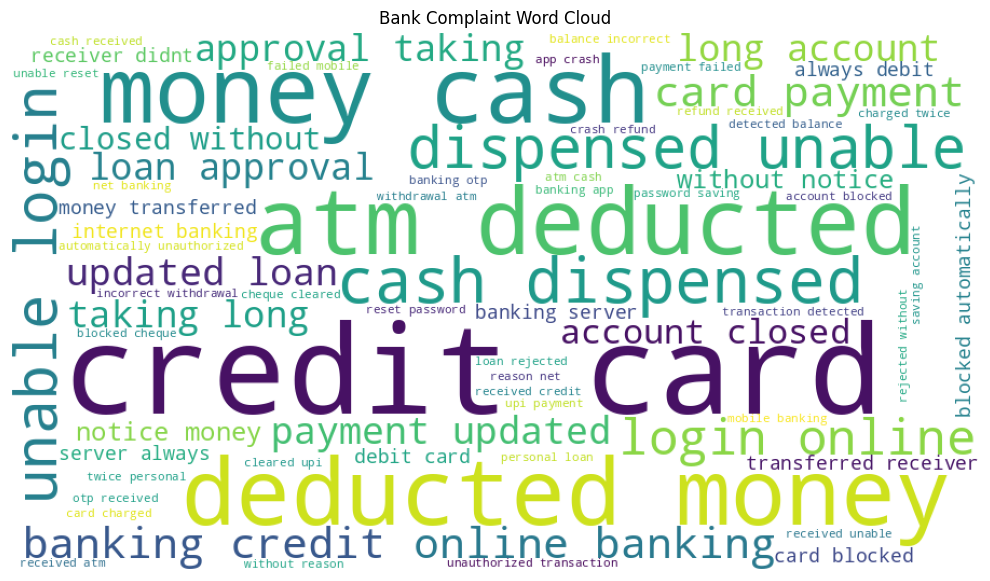

In [18]:
wordcloud=WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Bank Complaint Word Cloud")
plt.show()

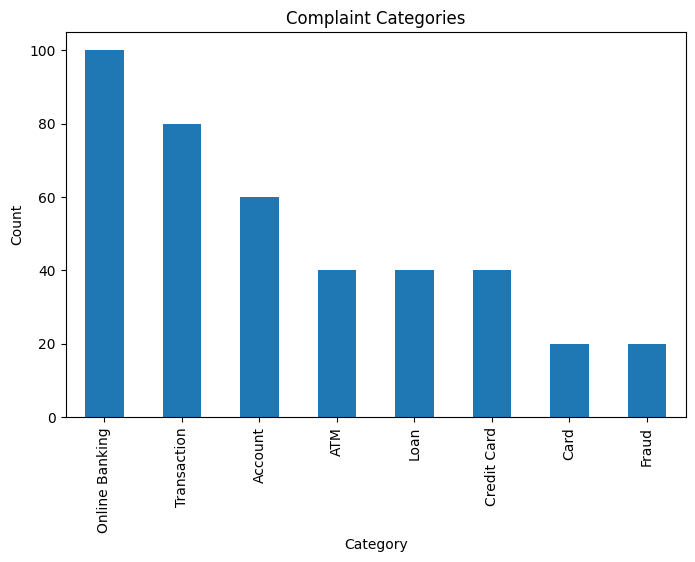

In [19]:
plt.figure(figsize=(8,5))

df["Category"].value_counts().plot(kind="bar")

plt.title("Complaint Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()


In [20]:
print("\n========================================")
print("BANK COMPLAINT ANALYSIS REPORT")
print("========================================")

print("\nTotal Complaints :",len(df))

print("\nComplaint Categories")

print(df["Category"].value_counts())

print("\nTop 10 Frequent Issues")

for word,count in frequency.most_common(10):
    print(word,":",count)

print("\nSuggested Improvements")

print("- Improve ATM reliability")
print("- Reduce loan approval time")
print("- Improve Online Banking uptime")
print("- Secure customer transactions")
print("- Faster refund processing")
print("- Improve account management")

print("\nAnalysis Completed Successfully.")


BANK COMPLAINT ANALYSIS REPORT

Total Complaints : 400

Complaint Categories
Category
Online Banking    100
Transaction        80
Account            60
ATM                40
Loan               40
Credit Card        40
Card               20
Fraud              20
Name: count, dtype: int64

Top 10 Frequent Issues
banking : 80
card : 60
received : 60
atm : 40
money : 40
cash : 40
unable : 40
credit : 40
payment : 40
loan : 40

Suggested Improvements
- Improve ATM reliability
- Reduce loan approval time
- Improve Online Banking uptime
- Secure customer transactions
- Faster refund processing
- Improve account management

Analysis Completed Successfully.
